### importing packages and dataset

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import time
df = pd.read_csv("student_mental_health_burnout_1M.csv")

### checking dataset

In [3]:
print(df.shape)
df.head()

(1000000, 20)


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


### removing missing values

In [4]:
df.dropna(inplace=True)
print(df.shape)

(1000000, 20)


### selecting sample using stratified sampling

In [5]:
df_sample, _ = train_test_split(
    df,
    train_size=100000,
    stratify=df["risk_level"],
    random_state=42
)
print(df_sample.shape)

(100000, 20)


### encoding gender

In [6]:
encoder = LabelEncoder()
df_sample["gender"] = encoder.fit_transform(df_sample["gender"])

### feature selection 

In [8]:
selected_features = [
    "study_hours_per_day",
    "exam_pressure",
    "stress_level",
    "anxiety_score",
    "depression_score",
    "sleep_hours",
    "physical_activity",
    "social_support",
    "financial_stress",
    "family_expectation",
    "mental_health_index",
    "burnout_score"

]
df_selected = df_sample[selected_features]
X = df_selected.drop(columns=["burnout_score"])
y = df_selected["burnout_score"]
print(df_selected.shape)

(100000, 12)


### train test split

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### evaluate function

In [13]:
import time
import numpy as np

def evaluate_model(model, name):

    print("="*60)
    print(name)
    print("="*60)

    start = time.time()

    model.fit(X_train, y_train)

    end = time.time()

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    print(f"Training Time : {end-start:.2f} seconds")
    print(f"MAE           : {mae:.4f}")
    print(f"RMSE          : {rmse:.4f}")
    print(f"R² Score      : {r2:.4f}")
    print()
    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Time": end-start
    }

### Random forest

In [14]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model(rf,"Random Forest")

Random Forest
Training Time : 114.76 seconds
MAE           : 0.6538
RMSE          : 0.8623
R² Score      : 0.7283



### LightGBM

In [15]:
lgb = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb_results = evaluate_model(lgb,"LightGBM")

LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010489 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 11
[LightGBM] [Info] Start training from score 1.784803
Training Time : 5.60 seconds
MAE           : 0.6405
RMSE          : 0.8455
R² Score      : 0.7388



### XGBOOST

In [16]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_results = evaluate_model(xgb,"XGBoost")

XGBoost
Training Time : 3.75 seconds
MAE           : 0.6411
RMSE          : 0.8470
R² Score      : 0.7379



### CATBOOST

In [17]:
cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=False,
    random_state=42
)

cat_results = evaluate_model(cat,"CatBoost")

CatBoost
Training Time : 9.67 seconds
MAE           : 0.6382
RMSE          : 0.8426
R² Score      : 0.7406



### Comparing results

In [18]:
results = pd.DataFrame([
    rf_results,
    xgb_results,
    lgb_results,
    cat_results
])

results.sort_values(
    by="R2",
    ascending=False,
    inplace=True
)

results.reset_index(drop=True, inplace=True)

results

,Model,MAE,RMSE,R2,Time
0,CatBoost,0.638190,0.842606,0.740588,9.667212
1,LightGBM,0.640479,0.845456,0.738830,5.601484
2,XGBoost,0.641104,0.847004,0.737873,3.746989
3,Random Forest,0.653798,0.862328,0.728302,114.758068


### model training

In [19]:
from catboost import CatBoostRegressor

final_model = CatBoostRegressor(

    iterations=500,
    learning_rate=0.05,
    depth=6,

    loss_function='RMSE',

    random_state=42,

    verbose=False
)

final_model.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=False)

### predicting

In [20]:
predictions = final_model.predict(X_test)

### model evaluation

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("========== MODEL PERFORMANCE ==========")

print("MAE :", round(mae,4))

print("MSE :", round(mse,4))

print("RMSE:", round(rmse,4))

print("R² Score:", round(r2,4))

========== MODEL PERFORMANCE ==========
MAE : 0.638
MSE : 0.7104
RMSE: 0.8429
R² Score: 0.7404


### feature importance 

In [22]:
feature_importance = final_model.get_feature_importance()
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":feature_importance

})

importance.sort_values(

    by="Importance",

    ascending=False,

    inplace=True
)
importance

,Feature,Importance
10,mental_health_index,53.712270
5,sleep_hours,15.345107
7,social_support,10.809009
1,exam_pressure,7.790896
2,stress_level,7.469375
4,depression_score,1.276634
3,anxiety_score,0.960796
8,financial_stress,0.710793
0,study_hours_per_day,0.706115
6,physical_activity,0.625640


### plot feature importance

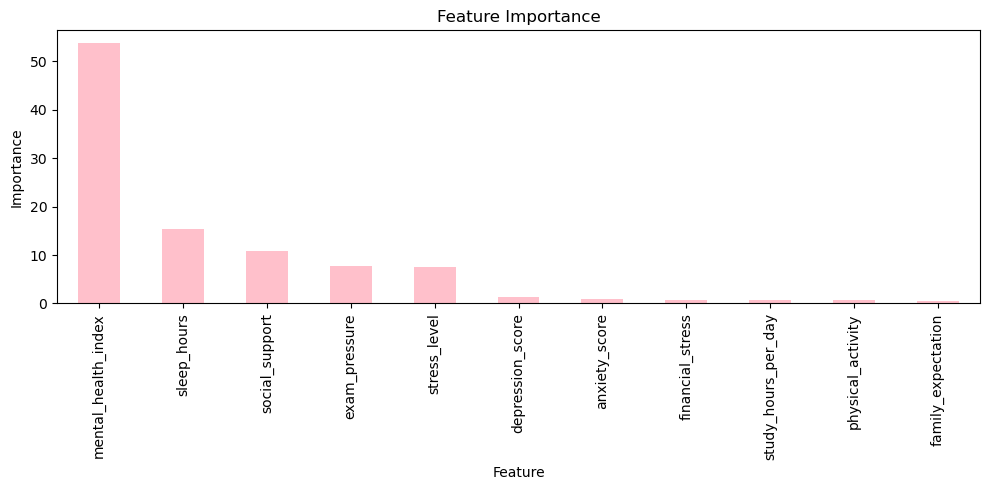

In [27]:
import matplotlib.pyplot as plt

importance.plot(

    x="Feature",

    y="Importance",

    kind="bar",

    figsize=(10,5),

    legend=False,
    color='pink'

)

plt.title("Feature Importance")

plt.ylabel("Importance")

plt.tight_layout()

plt.show()

### saving model

In [28]:
import joblib
joblib.dump(final_model,"burnout_model.pkl")

['burnout_model.pkl']

### loading the model

In [29]:
model = joblib.load("burnout_model.pkl")

### dummy data

In [45]:
dummy_student = pd.DataFrame({
    "study_hours_per_day":[4],
    "exam_pressure":[9],
    "stress_level":[8],
    "anxiety_score":[9],
    "depression_score":[8],
    "sleep_hours":[3],
    "physical_activity":[1],
    "social_support":[2],
    "financial_stress":[9],
    "family_expectation":[9],
    "mental_health_index":[0]
})

### predicting

In [46]:
predicted_burnout = final_model.predict(dummy_student)
print("Predicted Burnout Score:",round(predicted_burnout[0],2))

Predicted Burnout Score: 7.89


In [47]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    df_sample[["burnout_score"]],
    df_sample["dropout_risk"]
)

slope = lr.coef_[0]
intercept = lr.intercept_

print("Slope:", slope)
print("Intercept:", intercept)
predicted_dropout = (
    slope * predicted_burnout[0]
    + intercept
)

predicted_dropout = max(0,min(1,predicted_dropout))

print("Predicted Dropout Risk:",round(predicted_dropout,2))

Slope: 0.5607072956435384
Intercept: 0.3290912059667337
Predicted Dropout Risk: 1


In [48]:
df_sample.groupby("risk_level")["burnout_score"].agg(["min","max","mean"])

,min,max,mean
risk_level,,,
High,6.000194,10.000000,6.698521
Low,0.000000,2.999931,1.047118
Medium,3.000006,5.999823,4.037137


In [49]:
burnout = predicted_burnout[0]

if burnout < 3.5:
    risk = "Low"

elif burnout < 7:
    risk = "Medium"

else:
    risk = "High"

print("Risk Level:", risk)

Risk Level: High


In [37]:
import joblib

joblib.dump(final_model, "burnout_model.pkl")
joblib.dump(lr, "dropout_model.pkl")


['dropout_model.pkl']